# 13강. 추가실습 자료 - 푸리에 변환과 주파수 필터링

**2026-1 영상정보처리 | 김하연**

10강 이론에서 배운 푸리에 변환과 주파수 필터링을 numpy/OpenCV로 직접 구현해봅니다.

## 실습 목표
1. **1D 푸리에 분해** — 사각파를 사인파의 합으로 재구성
2. **2D 사인파 갤러리** — 주파수, 방향, 진폭 변화
3. **이미지 DFT와 스펙트럼 시각화** — log 스케일, fftshift
4. **패턴별 스펙트럼** — 직교성 (수직 줄무늬 → 가로 점)
5. **자연 이미지의 1/f 특성** — 라디얼 평균
6. **주파수 필터링** — LPF, HPF
7. **이상적 필터의 함정** — Ringing 현상
8. **컨볼루션 정리 검증** — 공간 Blur ≡ 주파수 도장
9. **커널 크기와 대역폭의 반비례 관계**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import platform

# 한글 폰트
if platform.system() == 'Windows':
    rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    rcParams['font.family'] = 'AppleGothic'
else:
    rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

print("OpenCV 버전:", cv2.__version__)


OpenCV 버전: 4.13.0


In [2]:
def show(imgs, titles, figsize=(15, 5), cmap='gray'):
    """이미지 여러 개를 한 줄로 출력"""
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


---
## 1. 1D 푸리에: 사각파를 사인파 합으로 만들기

10강 슬라이드 3 재현. 사각파의 푸리에 급수:

$$\text{square}(x) = \frac{4}{\pi} \sum_{k=1}^{N} \frac{\sin((2k-1)x)}{2k-1}$$

홀수배 고조파만 더해도 N이 커질수록 사각파에 가까워진다는 사실을 시각적으로 확인.


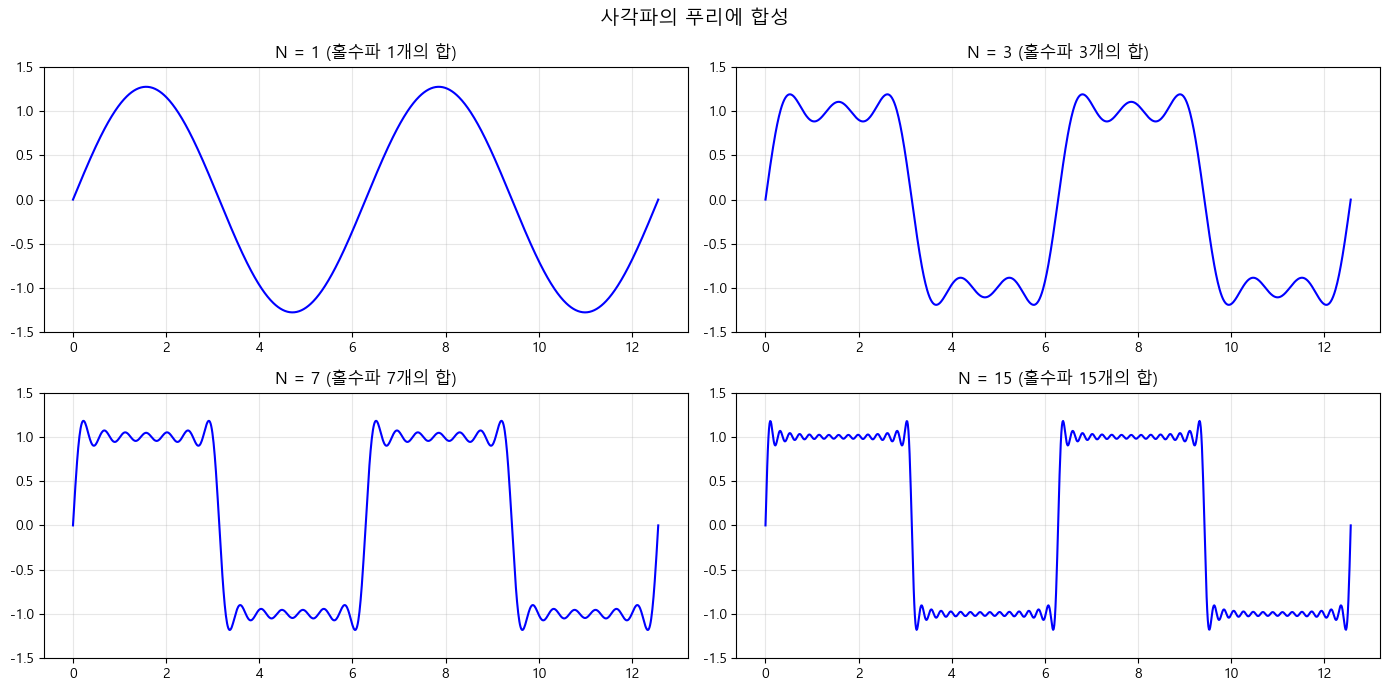

In [3]:
x = np.linspace(0, 4*np.pi, 1000)

def square_approx(x, N):
    """홀수 고조파 N개를 더한 사각파 근사"""
    y = np.zeros_like(x)
    for k in range(1, N+1):
        n = 2*k - 1  # 1, 3, 5, 7, ...
        y += np.sin(n*x) / n
    return (4/np.pi) * y

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, N in zip(axes.flat, [1, 3, 7, 15]):
    ax.plot(x, square_approx(x, N), 'b-', linewidth=1.5)
    ax.set_title(f'N = {N} (홀수파 {N}개의 합)')
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
plt.suptitle('사각파의 푸리에 합성', fontsize=14)
plt.tight_layout()
plt.show()


### 톱니파: 모든 정수배 고조파를 더하면

$$\text{sawtooth}(x) = -\frac{2}{\pi} \sum_{n=1}^{N} \frac{(-1)^n \sin(nx)}{n}$$


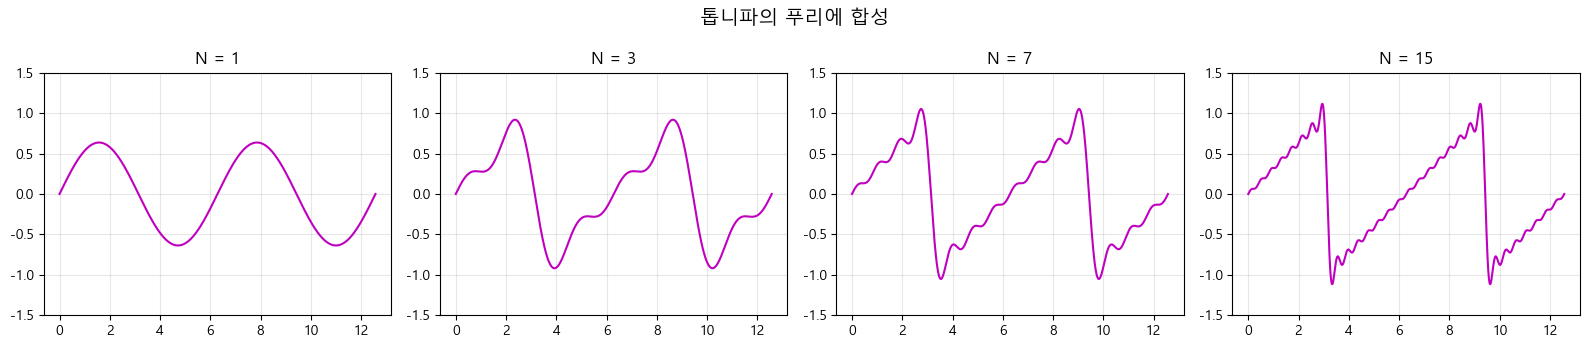

In [4]:
def sawtooth_approx(x, N):
    """모든 정수 고조파 N개를 더한 톱니파 근사"""
    y = np.zeros_like(x)
    for n in range(1, N+1):
        y += ((-1)**(n+1)) * np.sin(n*x) / n
    return (2/np.pi) * y

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, N in zip(axes, [1, 3, 7, 15]):
    ax.plot(x, sawtooth_approx(x, N), 'm-', linewidth=1.5)
    ax.set_title(f'N = {N}')
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
plt.suptitle('톱니파의 푸리에 합성', fontsize=14)
plt.tight_layout()
plt.show()


---
## 2. 2D 사인파 갤러리: 주파수, 방향, 진폭

10강 슬라이드 6 재현. 2D 사인파:

$$I(x, y) = A \cdot \sin(ux + vy + \varphi)$$

- **(u, v) 크기** → 주파수 (줄무늬 촘촘함)
- **(u, v) 방향** → 줄무늬 방향
- **A** → 진폭 (대비)


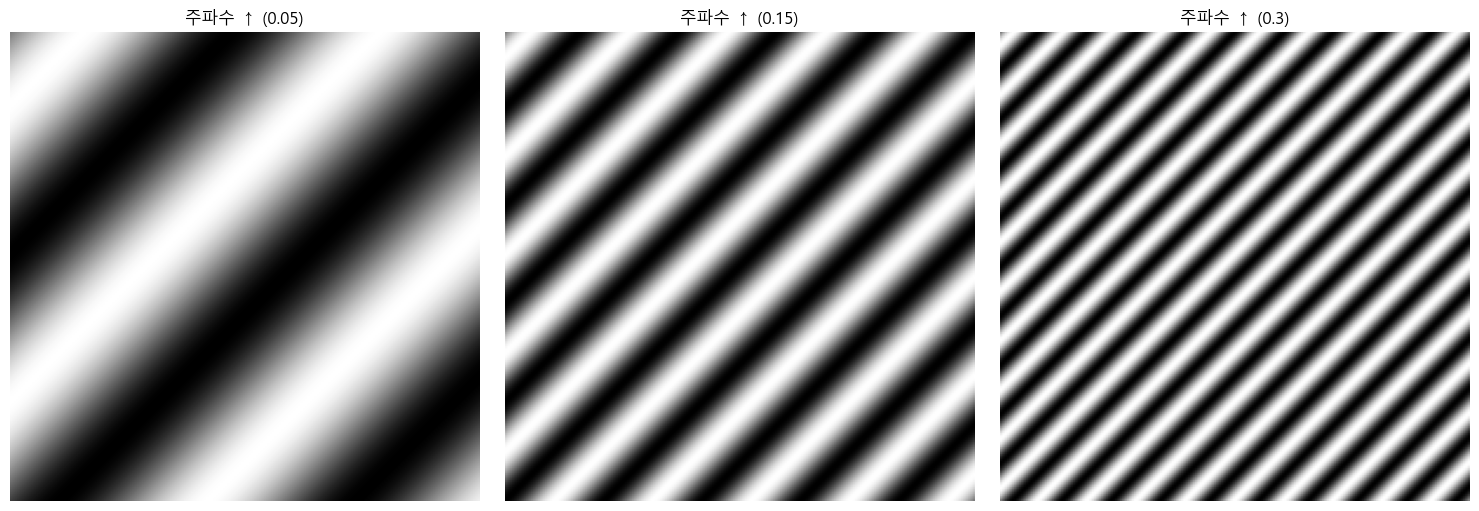

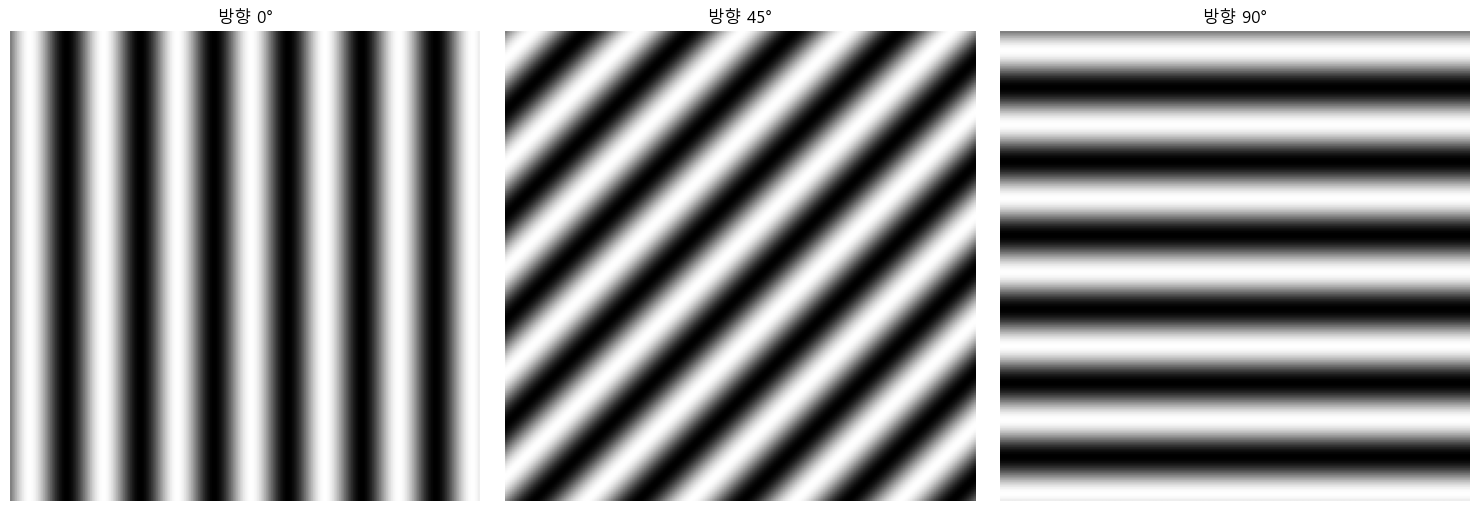

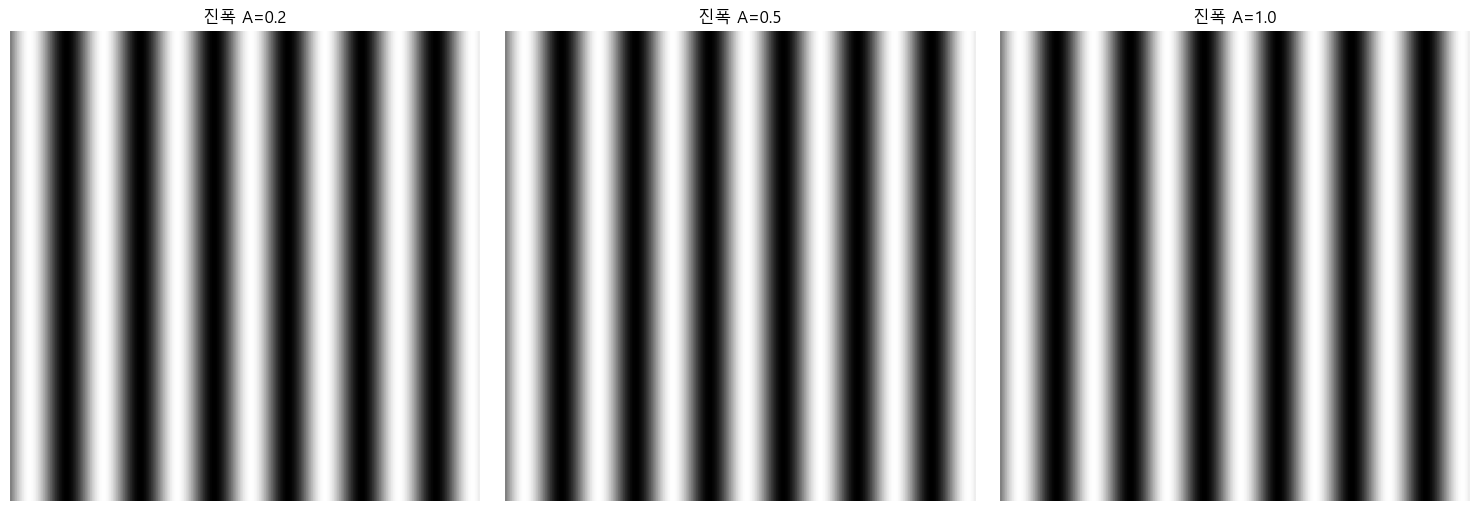

In [5]:
def sinusoid_2d(size, u, v, A=1.0, phi=0.0):
    """I(x,y) = A * sin(ux + vy + phi)"""
    y, x = np.indices((size, size))
    return A * np.sin(u*x + v*y + phi)

size = 200

# 1) 주파수 변화 (방향 45° 고정)
freqs = [0.05, 0.15, 0.30]
imgs_f = [sinusoid_2d(size, f, f) for f in freqs]
show(imgs_f, [f'주파수 ↑ ({f})' for f in freqs])

# 2) 방향 변화 (주파수 고정)
angles = [0, 45, 90]
imgs_a = []
for a in angles:
    rad = np.deg2rad(a)
    imgs_a.append(sinusoid_2d(size, 0.2*np.cos(rad), 0.2*np.sin(rad)))
show(imgs_a, [f'방향 {a}°' for a in angles])

# 3) 진폭 변화 (주파수, 방향 고정)
amps = [0.2, 0.5, 1.0]
imgs_amp = [sinusoid_2d(size, 0.2, 0, A=a) for a in amps]
show(imgs_amp, [f'진폭 A={a}' for a in amps])


---
## 3. 이미지의 DFT와 주파수 스펙트럼

`numpy.fft.fft2`로 2D DFT를 계산하고, `fftshift`로 DC 성분을 중앙으로 이동.
자연 이미지는 저주파 에너지가 압도적이라 **로그 스케일**로 변환해야 고주파 디테일이 보임.


이미지 크기: (480, 640)


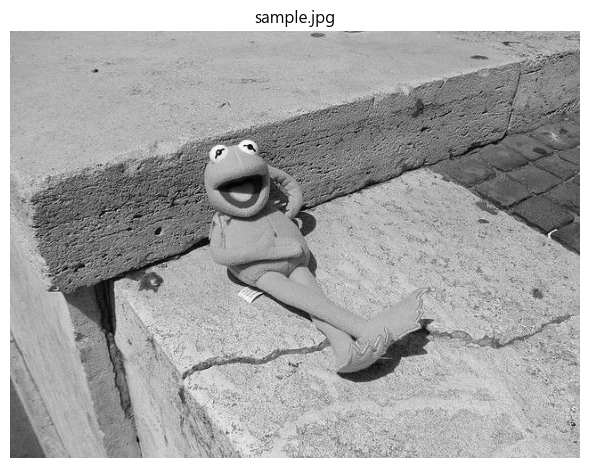

In [6]:
# sample.jpg 로드 (그레이스케일)
img = cv2.imread('sample.jpg', cv2.IMREAD_GRAYSCALE)
assert img is not None, "sample.jpg를 찾을 수 없습니다. 노트북과 같은 폴더에 두세요."

print(f"이미지 크기: {img.shape}")
show([img], ['sample.jpg'], figsize=(6, 6))


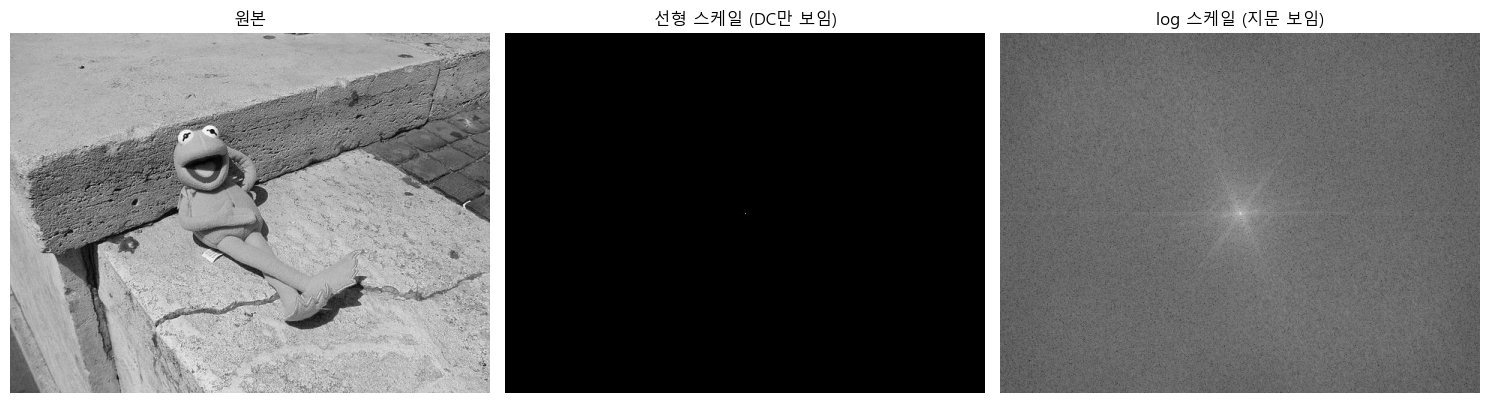

In [7]:
def compute_log_spectrum(img):
    """DFT → 중앙 이동 → 진폭 → log 스케일"""
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)       # DC를 중앙으로
    magnitude = np.abs(fshift)
    return np.log(magnitude + 1)      # log(1+x)로 평탄화

log_spec = compute_log_spectrum(img)

# 비교: log 스케일 vs 선형 스케일
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
linear_spec = np.abs(fshift)

show([img, linear_spec, log_spec],
     ['원본', '선형 스케일 (DC만 보임)', 'log 스케일 (지문 보임)'])


---
## 4. 패턴이 스펙트럼에 남기는 흔적 (직교성)

10강 슬라이드 9 재현. **공간에서의 패턴 방향과 스펙트럼의 점 위치는 정확히 90° 직교**.

- 강한 **세로 줄무늬** → x축으로 요동침 → **가로 방향 스펙트럼 점**
- 강한 **가로 줄무늬** → y축으로 요동침 → **세로 방향 스펙트럼 점**
- **격자(체크무늬)** → 두 방향 결합 → **십자가 패턴**


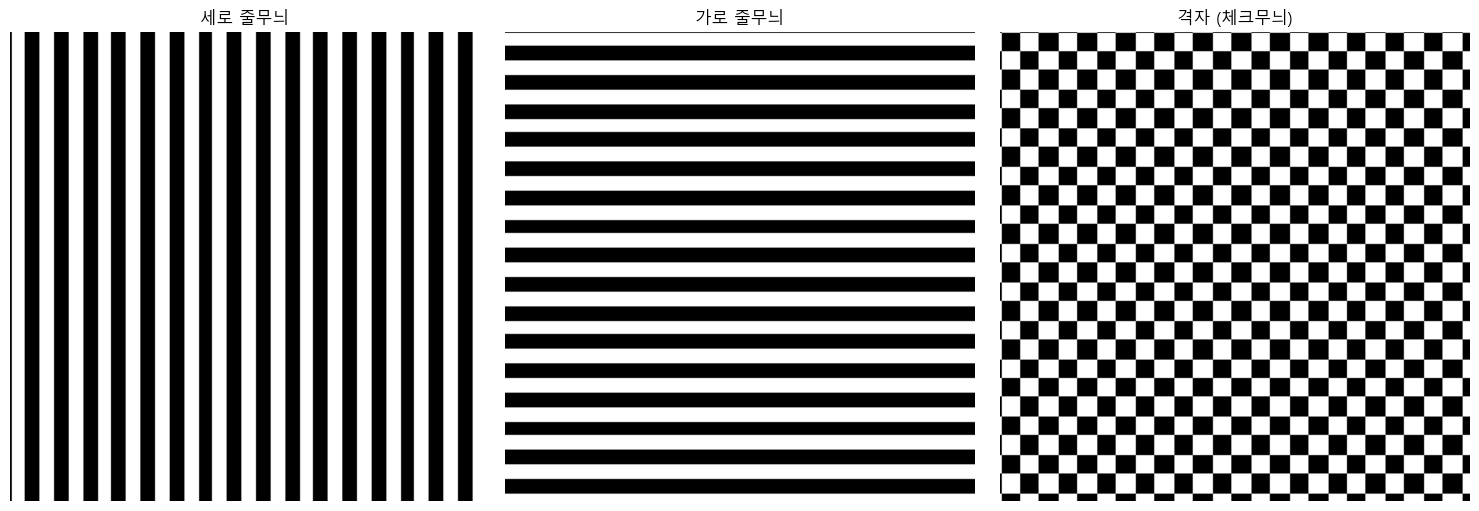

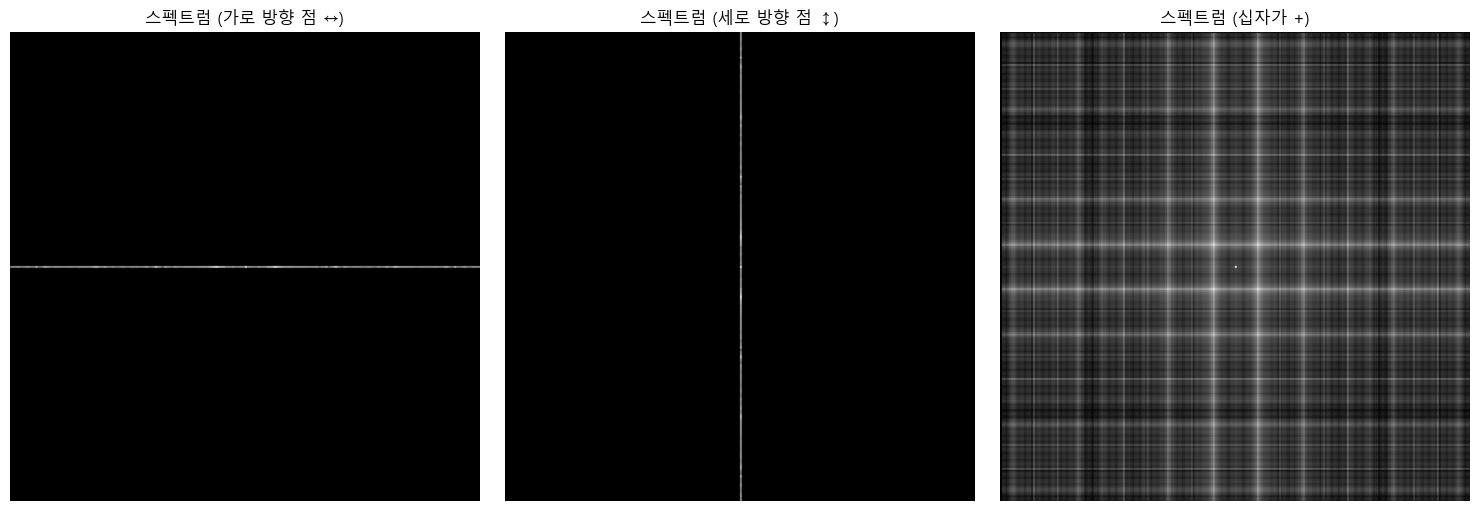

In [8]:
size = 256
y_idx, x_idx = np.indices((size, size))

# 세로 줄무늬: x 방향으로 변동
vert = (np.sin(x_idx * 0.4) > 0).astype(np.float32)
# 가로 줄무늬: y 방향으로 변동
hori = (np.sin(y_idx * 0.4) > 0).astype(np.float32)
# 격자: 두 방향 XOR
check = ((np.sin(x_idx*0.3) > 0) ^ (np.sin(y_idx*0.3) > 0)).astype(np.float32)

show([vert, hori, check],
     ['세로 줄무늬', '가로 줄무늬', '격자 (체크무늬)'])

show([compute_log_spectrum(vert),
      compute_log_spectrum(hori),
      compute_log_spectrum(check)],
     ['스펙트럼 (가로 방향 점 ↔)',
      '스펙트럼 (세로 방향 점 ↕)',
      '스펙트럼 (십자가 +)'])


---
## 5. 자연 이미지의 1/f 특성

10강 슬라이드 11 재현. 주파수가 높아질수록 진폭이 반비례하여 감소.
스펙트럼을 중심에서 외곽으로 **라디얼 평균**을 내면 확인 가능.


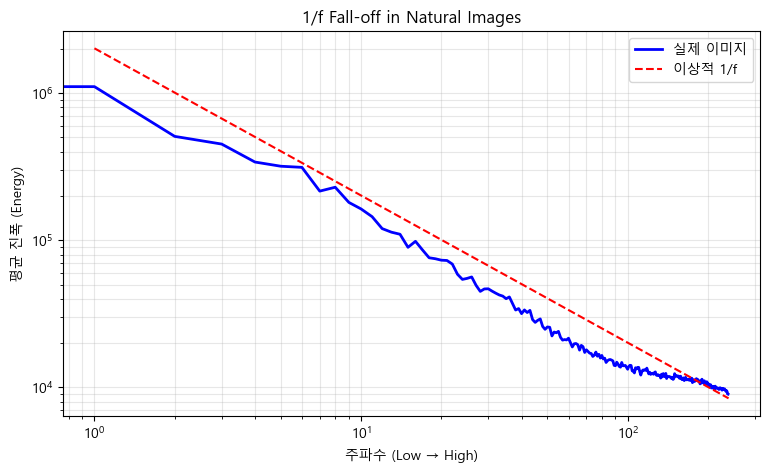

In [9]:
def radial_average(magnitude_spectrum):
    """중심으로부터 거리별 평균 진폭 (1D 프로파일)"""
    h, w = magnitude_spectrum.shape
    cy, cx = h//2, w//2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    rmax = min(cy, cx)
    return np.array([magnitude_spectrum[r == i].mean()
                     for i in range(rmax)])

# 진폭 스펙트럼에서 라디얼 평균
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude = np.abs(fshift)
ra = radial_average(magnitude)

# log-log 플롯으로 1/f 직선 관찰
plt.figure(figsize=(9, 5))
plt.loglog(ra[1:], 'b-', linewidth=2, label='실제 이미지')
freqs = np.arange(1, len(ra))
plt.loglog(freqs, ra[1] / freqs, 'r--', linewidth=1.5, label='이상적 1/f')
plt.xlabel('주파수 (Low → High)')
plt.ylabel('평균 진폭 (Energy)')
plt.title('1/f Fall-off in Natural Images')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


---
## 6. 주파수 필터링: LPF와 HPF

주파수 도메인에서 마스크를 곱한 뒤 역변환:

$$g(x, y) = \mathcal{F}^{-1}\big[ F(u,v) \cdot H(u,v) \big]$$

- **LPF**: 중심부 통과 → 고주파 차단 → 블러
- **HPF**: 중심부 차단 → 고주파 통과 → 에지만 남음


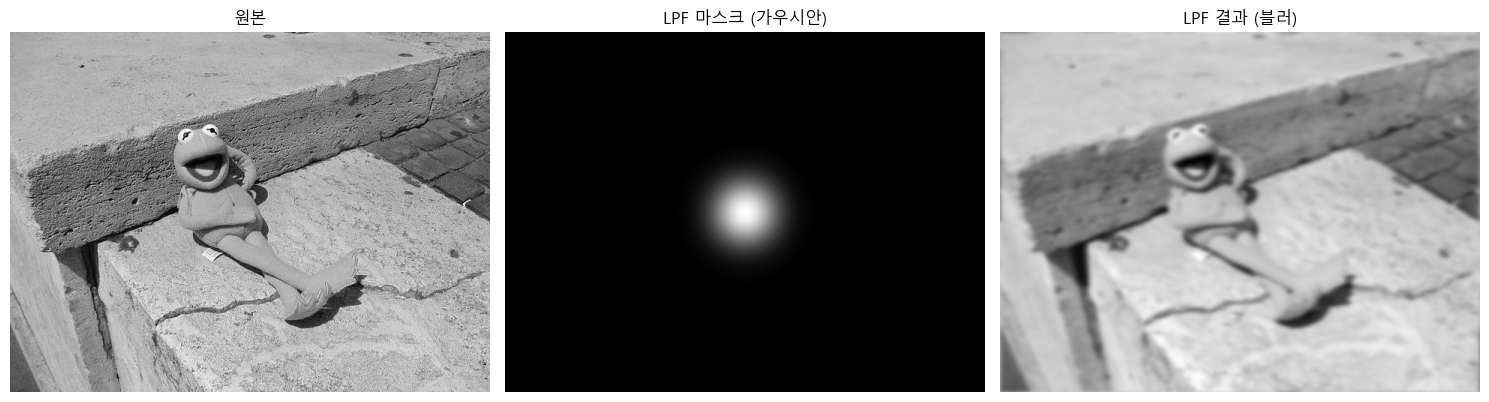

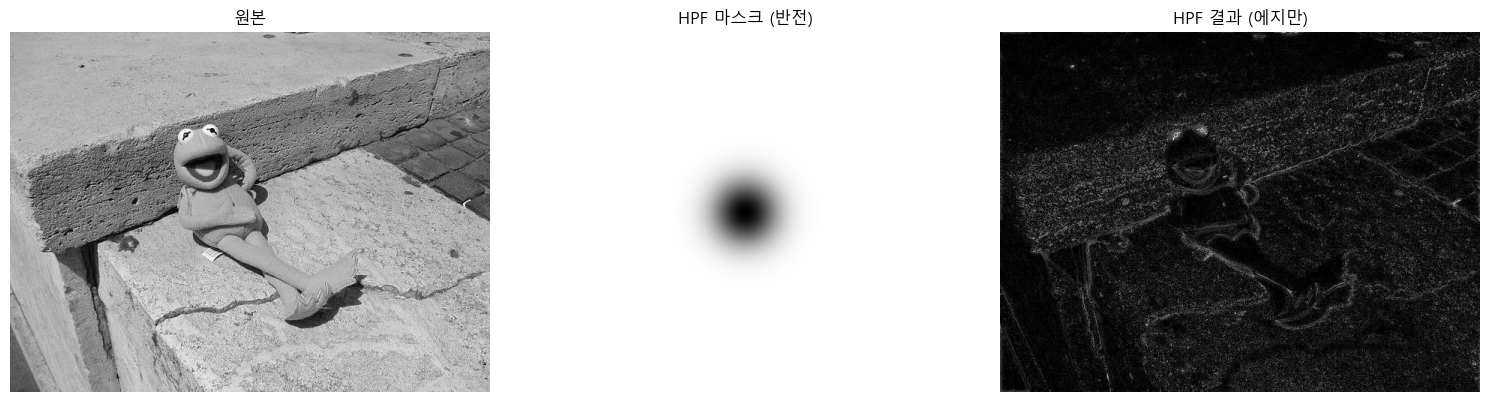

In [10]:
def make_gaussian_mask(shape, sigma, mode='lp'):
    """가우시안 마스크. mode='lp' (저역) 또는 'hp' (고역)"""
    h, w = shape
    cy, cx = h//2, w//2
    y, x = np.indices((h, w))
    d2 = (x - cx)**2 + (y - cy)**2
    g = np.exp(-d2 / (2 * sigma**2))
    return g if mode == 'lp' else 1 - g

def apply_freq_filter(img, mask):
    """FFT → 마스크 곱 → IFFT → 실수부 절댓값"""
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    filtered = fshift * mask
    f_ishift = np.fft.ifftshift(filtered)
    result = np.fft.ifft2(f_ishift)
    return np.abs(result)

# LPF
lpf_mask = make_gaussian_mask(img.shape, sigma=30, mode='lp')
img_lpf = apply_freq_filter(img, lpf_mask)

# HPF
hpf_mask = make_gaussian_mask(img.shape, sigma=30, mode='hp')
img_hpf = apply_freq_filter(img, hpf_mask)

show([img, lpf_mask, img_lpf],
     ['원본', 'LPF 마스크 (가우시안)', 'LPF 결과 (블러)'])

show([img, hpf_mask, img_hpf],
     ['원본', 'HPF 마스크 (반전)', 'HPF 결과 (에지만)'])


---
## 7. 이상적 필터의 함정 - Ringing 현상

10강 슬라이드 12-13 재현. 1과 0을 칼같이 자르는 이상적 필터는 직관적으로는 완벽해 보이지만,
공간 도메인으로 역변환하면 **에지 주변에 잔물결(Ringing)이 무한히 퍼짐**.


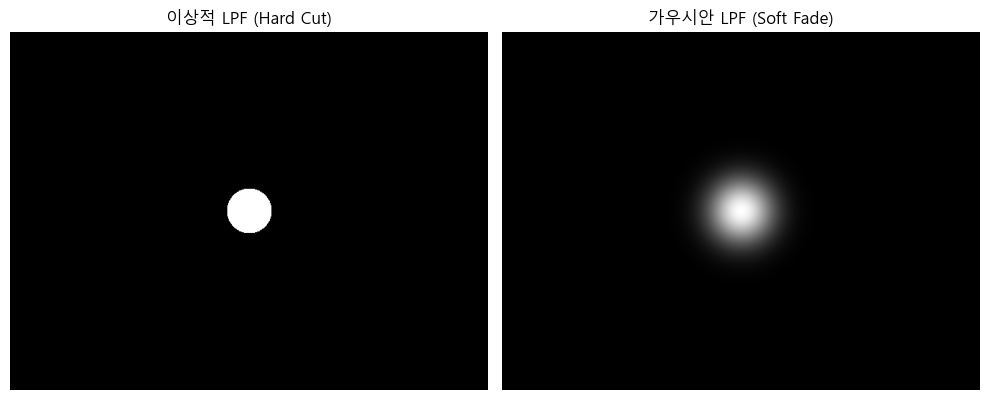

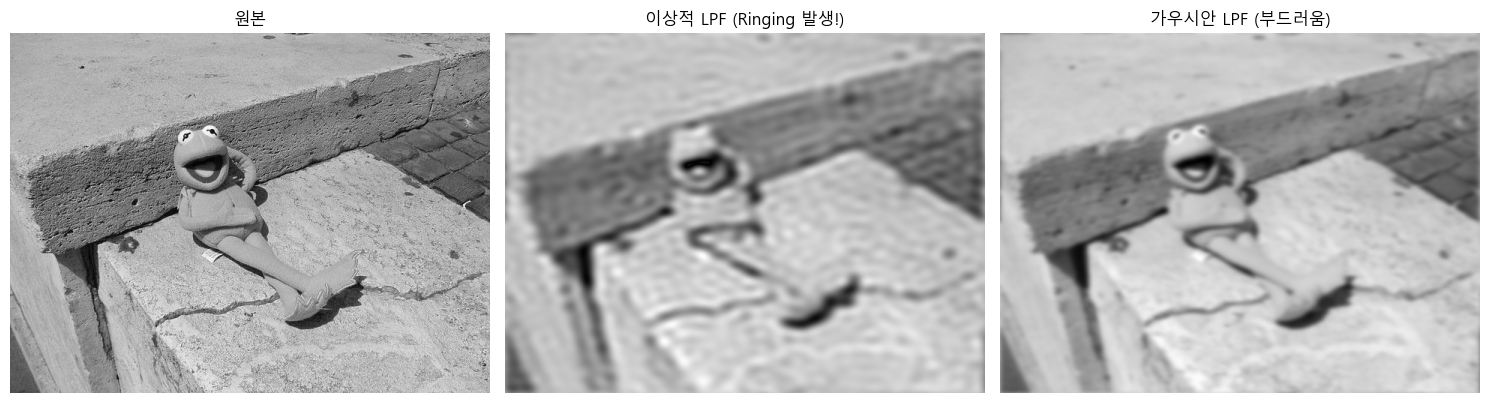

In [11]:
def make_ideal_mask(shape, radius):
    """하드 컷오프 원형 마스크"""
    h, w = shape
    cy, cx = h//2, w//2
    y, x = np.indices((h, w))
    d = np.sqrt((x - cx)**2 + (y - cy)**2)
    return (d < radius).astype(np.float32)

ideal_mask = make_ideal_mask(img.shape, 30)
gauss_mask = make_gaussian_mask(img.shape, 30, 'lp')

img_ideal = apply_freq_filter(img, ideal_mask)
img_gauss = apply_freq_filter(img, gauss_mask)

# 마스크 비교
show([ideal_mask, gauss_mask],
     ['이상적 LPF (Hard Cut)', '가우시안 LPF (Soft Fade)'],
     figsize=(10, 5))

# 결과 비교 - Ringing 확인
show([img, img_ideal, img_gauss],
     ['원본', '이상적 LPF (Ringing 발생!)', '가우시안 LPF (부드러움)'])


### Ringing 확대 관찰

원의 경계 부근을 잘라서 보면 잔물결이 명확히 보입니다.


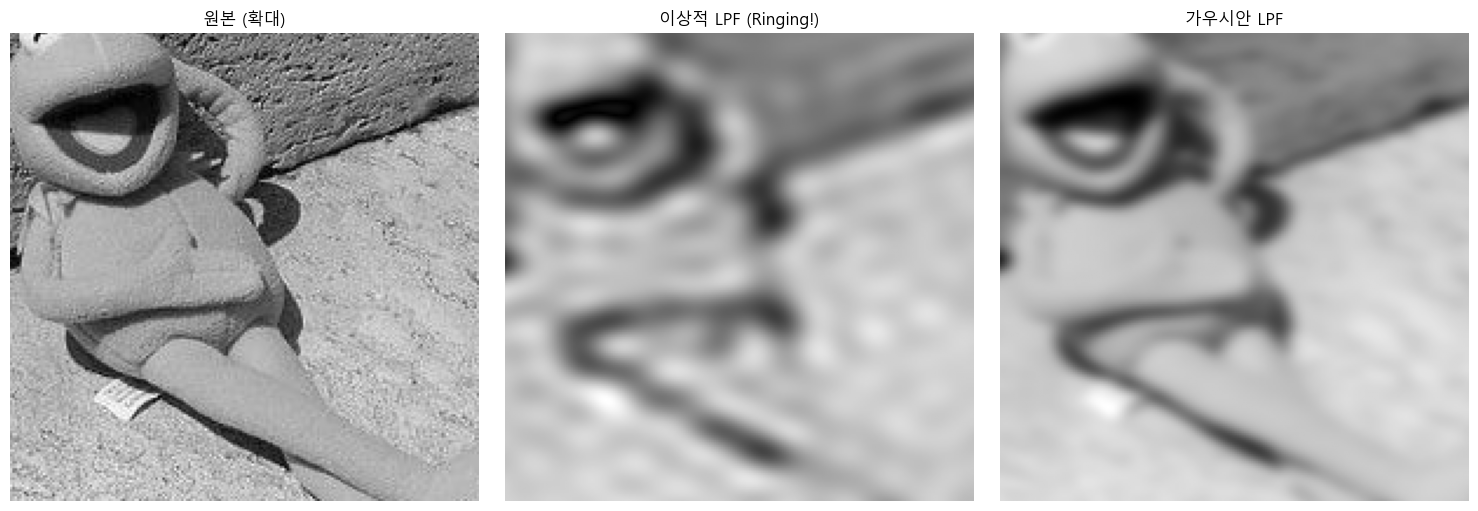

In [12]:
# 원 경계 부근 ROI 잘라서 확대
y0, y1 = img.shape[0]//2 - 100, img.shape[0]//2 + 100
x0, x1 = img.shape[1]//2 - 100, img.shape[1]//2 + 100

show([img[y0:y1, x0:x1],
      img_ideal[y0:y1, x0:x1],
      img_gauss[y0:y1, x0:x1]],
     ['원본 (확대)', '이상적 LPF (Ringing!)', '가우시안 LPF'],
     figsize=(15, 5))


---
## 8. 컨볼루션 정리 검증

10강 슬라이드 14의 핵심 법칙:

$$f(x, y) * h(x, y) \Longleftrightarrow F(u, v) \cdot H(u, v)$$

**공간 도메인의 가우시안 컨볼루션 ≡ 주파수 도메인의 가우시안 곱셈**.
같은 결과가 나오는지 직접 확인.


두 결과의 평균 절대 오차: 1.57


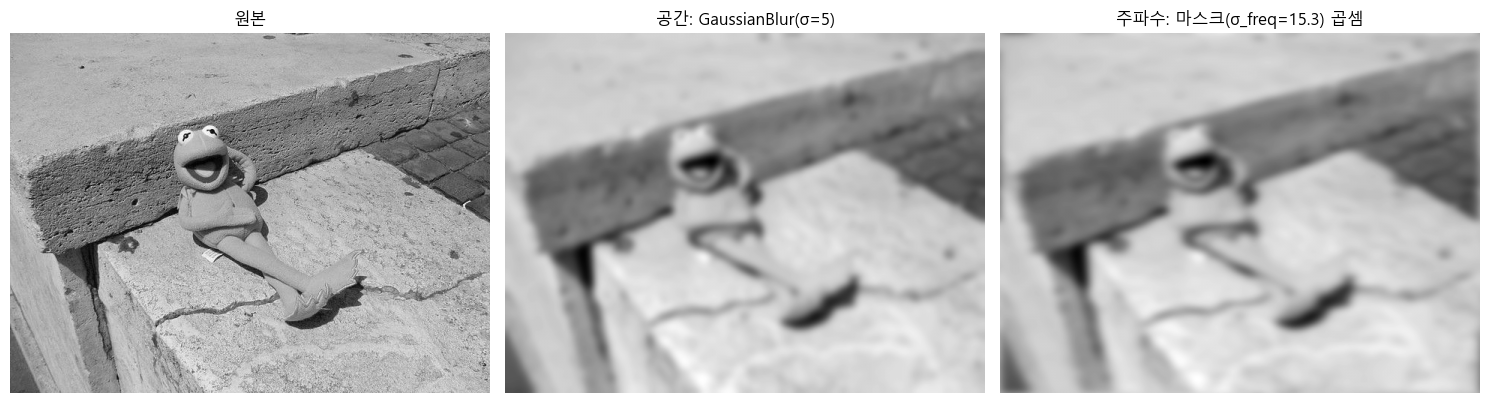

In [13]:
# (1) 공간 도메인: cv2.GaussianBlur
sigma = 5
blurred_spatial = cv2.GaussianBlur(img, ksize=(0, 0), sigmaX=sigma)

# (2) 주파수 도메인: 가우시안 마스크 곱셈
# 공간의 σ와 주파수의 σ는 반비례: σ_freq = N / (2π σ_spatial)
N = img.shape[0]
sigma_freq = N / (2 * np.pi * sigma)
freq_mask = make_gaussian_mask(img.shape, sigma_freq, 'lp')
blurred_freq = apply_freq_filter(img, freq_mask)

# 두 결과의 차이
diff = np.abs(blurred_spatial.astype(float) - blurred_freq)
print(f"두 결과의 평균 절대 오차: {diff.mean():.2f}")

show([img, blurred_spatial, blurred_freq.astype(np.uint8)],
     ['원본', '공간: GaussianBlur(σ=5)', f'주파수: 마스크(σ_freq={sigma_freq:.1f}) 곱셈'])


**결론**: 공간 도메인에서 픽셀 위에 커널을 굴리던 행위는 주파수 도메인에서 마스크를 곱하는 행위와 수학적으로 동일.


---
## 9. 커널 크기 vs 대역폭 (반비례 법칙)

10강 슬라이드 15-16 재현. **공간에서 좁은 = 주파수에서 넓다.**

- 작은 σ (공간 좁음) → 주파수 마스크 넓음 → 고주파 많이 살아남음 → 약한 블러
- 큰 σ (공간 넓음) → 주파수 마스크 좁음 → 고주파 잘림 → 강한 블러


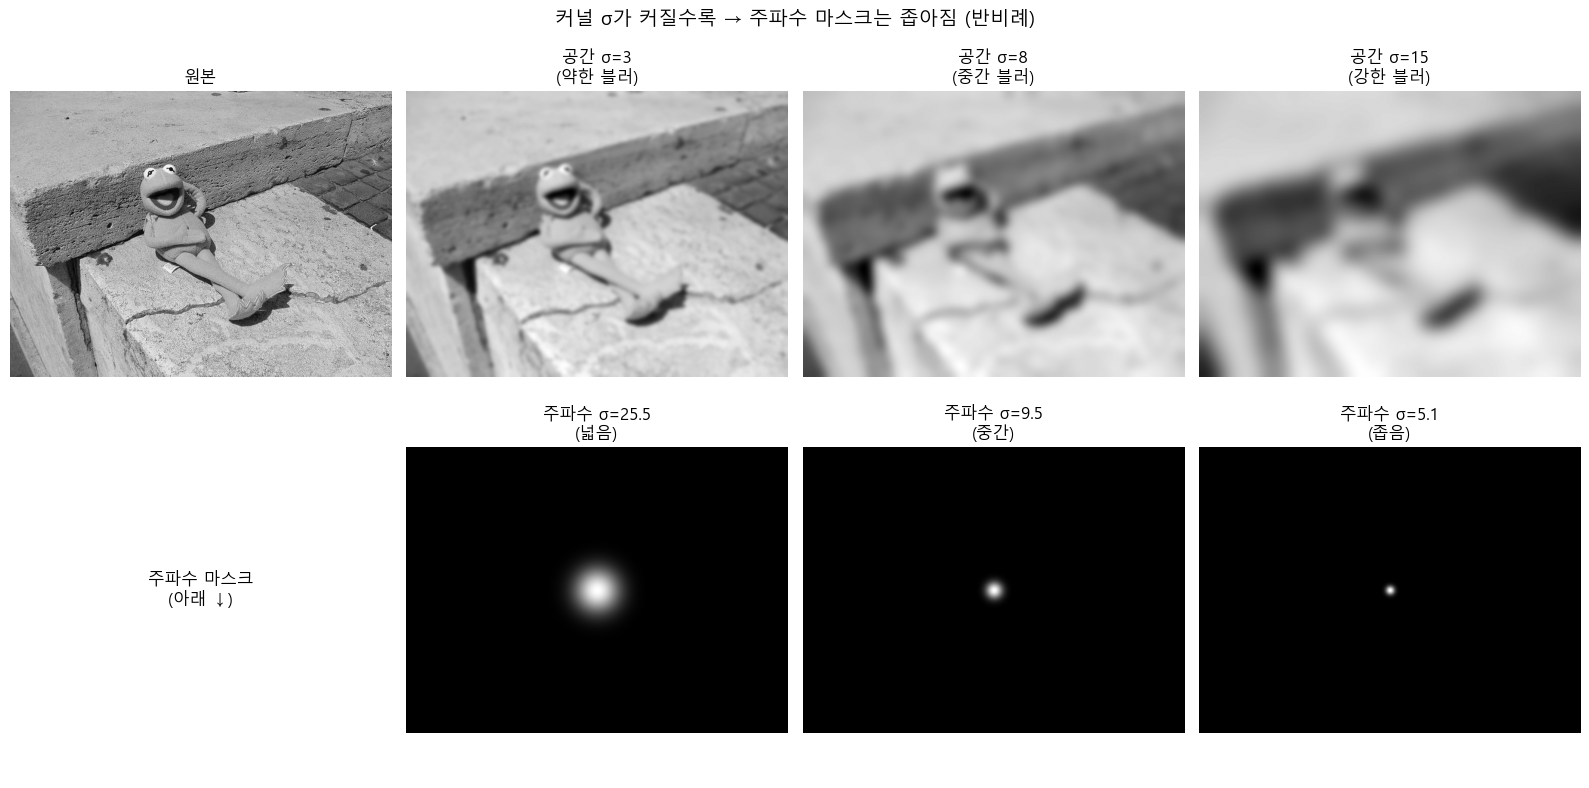

In [14]:
sigmas = [3, 8, 15]
N = img.shape[0]

fig, axes = plt.subplots(2, len(sigmas)+1, figsize=(16, 8))

# 첫 열: 원본
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('원본')
axes[0, 0].axis('off')
axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, '주파수 마스크\n(아래 ↓)',
                ha='center', va='center', transform=axes[1, 0].transAxes,
                fontsize=12)

for i, sig in enumerate(sigmas):
    # 위: 공간 도메인 블러 결과
    blurred = cv2.GaussianBlur(img, (0, 0), sig)
    axes[0, i+1].imshow(blurred, cmap='gray')
    axes[0, i+1].set_title(f'공간 σ={sig}\n({"약한" if sig<=5 else "중간" if sig<=10 else "강한"} 블러)')
    axes[0, i+1].axis('off')
    
    # 아래: 대응하는 주파수 마스크
    sig_freq = N / (2 * np.pi * sig)
    mask = make_gaussian_mask(img.shape, sig_freq, 'lp')
    axes[1, i+1].imshow(mask, cmap='gray')
    axes[1, i+1].set_title(f'주파수 σ={sig_freq:.1f}\n({"넓음" if sig<=5 else "중간" if sig<=10 else "좁음"})')
    axes[1, i+1].axis('off')

plt.suptitle('커널 σ가 커질수록 → 주파수 마스크는 좁아짐 (반비례)', fontsize=14)
plt.tight_layout()
plt.show()


---
## 정리

| 도메인 | 연산 | 효과 |
|---|---|---|
| 공간 | $f * h$ (컨볼루션) | 픽셀 위에 커널 굴리기 |
| 주파수 | $F \cdot H$ (요소별 곱) | 스펙트럼에 도장 찍기 |

**공간 ↔ 주파수 반비례**:
- 좁은 공간 커널 ↔ 넓은 주파수 마스크 → 약한 블러
- 넓은 공간 커널 ↔ 좁은 주파수 마스크 → 강한 블러

**필터 설계 원리**:
- LPF (저주파만 통과) → 블러 / 노이즈 제거
- HPF (고주파만 통과) → 에지 강조
- 이상적 (하드 컷) → Ringing 발생 → 가우시안처럼 부드럽게 감쇠시켜야 함
